# Co2 Modelling

In [8]:
import pandas as pd

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = f"images/{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

def load_pandas_df_from_csv():
    return pd.read_csv("LAEI-2019-Emissions-Summary-including-Forecast/2019filteredatacsv.csv")

emissions_2019 = load_pandas_df_from_csv()

In [9]:
emissions_2019.drop(columns=[
    'Year', 'Emissions Unit', 'LAEI 1km2 ID', 'Grid ID 2019',
    'bap', 'cd', 'c4h6', 'c6h6', 'ch4', 'co', 'hc', 'hcl',
    'hg', 'n2o', 'nh3', 'nmvoc', 'pb', 'pcb', 'so2', 
    'nox', 'pm10', 'pm2.5'
], inplace=True)

In [10]:
emissions_2019.info()
emissions_2019['co2'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143976 entries, 0 to 143975
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Easting               143976 non-null  int64  
 1   Northing              143976 non-null  int64  
 2   Borough               143976 non-null  object 
 3   Zone                  143976 non-null  object 
 4   Main Source Category  143976 non-null  object 
 5   Sector                143976 non-null  object 
 6   Source                143976 non-null  object 
 7   co2                   112836 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 8.8+ MB


count    112836.000000
mean        257.580418
std        3642.241790
min           0.000000
25%           0.000000
50%           0.901680
75%          56.987074
max      747457.600000
Name: co2, dtype: float64

## Feature Engineering from Spatial Data

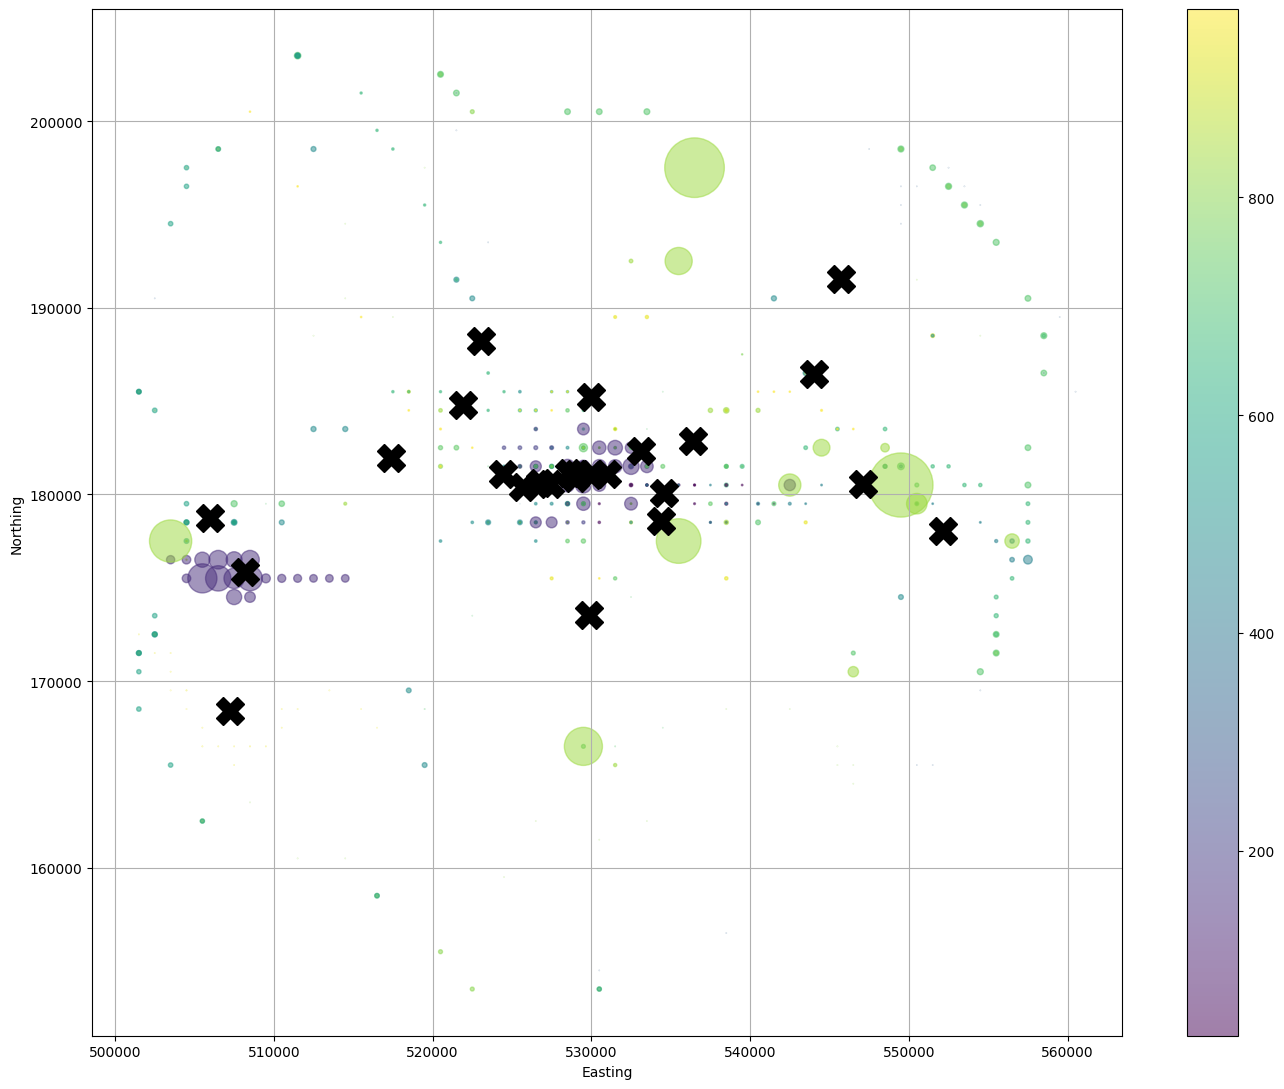

{'TfL Bus': array([[182317.89023658, 533144.06691077]]), 'Taxi': array([[180853.26024527, 528947.57147054]]), 'PHV - Petrol': array([[180616.44253736, 526757.23767713]]), 'PHV - Electric': array([], shape=(1, 0), dtype=float64), 'PHV - Diesel': array([[180390.50375203, 525718.68644519]]), 'Non-TfL Bus / Coach': array([[180568.50965636, 527382.3560983 ]]), 'Motorcycle': array([[181091.63012039, 531003.8719364 ]]), 'LGV - Petrol': array([[184777.21624066, 521944.82823621]]), 'LGV - Electric': array([], shape=(1, 0), dtype=float64), 'LGV - Diesel': array([[181105.63718875, 524433.68243028]]), 'HGV - Rigid': array([[180555.31298303, 547136.78189   ]]), 'HGV - Articulated': array([[191530.09758813, 545709.85605309]]), 'Car - Petrol': array([[181959.94767008, 517379.5564093 ]]), 'Car - Electric': array([], shape=(1, 0), dtype=float64), 'Car - Diesel': array([[178711.23007264, 505959.18363284]]), 'Small Private Vessels': array([[168375.14412168, 507210.99941477]]), 'Passenger Shipping': array

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# to start, fill co2 with 0 where NaN
emissions_2019['co2'] = emissions_2019['co2'].fillna(0)

# let's take the top 20 highest emitters by source
emissions_2019['rank'] = emissions_2019.groupby('Source')['co2'].rank(method='first', ascending=False)
top_emitters_by_source = emissions_2019[emissions_2019['rank'] <= 20]
emissions_2019.drop(columns=['rank'], inplace=True)

source_cluster_center_map = {}

# then, loop through all source sources
for source in top_emitters_by_source['Source'].unique():
    top_emitters_for_source = top_emitters_by_source[top_emitters_by_source['Source'] == source]
    
    # if this particular source doesn't produce any co2, we'll assign an
    # empty np array, and encode a fixed value later when computing similarity measures
    # -- hopefully the model learns this signals 'no co2 emissions for this source'.
    if (top_emitters_for_source['co2'] == 0).all():
        source_cluster_center_map[source] = np.array([[]])
        continue

    # otherwise, let's find where those high emitters for this source cluster
    # -- weight by co2 volume
    kmeans = KMeans(1, n_init=5, random_state=42)
    kmeans.fit_transform(
        top_emitters_for_source[['Northing', 'Easting']], 
        sample_weight=top_emitters_for_source['co2'])
    
    source_cluster_center_map[source] = kmeans.cluster_centers_

# now lets plot the high emitters and their cluster centers
top_emitters_by_source.plot(kind='scatter', x='Easting', y='Northing', grid=True, 
            s=top_emitters_by_source['co2'] / 350, # size based on volume of emissions
            c=top_emitters_by_source['Source'].apply(lambda s: hash(s) % 1000), # colour based on emission source - unique number from string
            cmap='viridis',
            alpha=0.5,
            figsize=(14,11))

for source, cluster_center in source_cluster_center_map.items():
    if cluster_center.size != 2:
        continue
    plt.plot(cluster_center[:, 1],
             cluster_center[:, 0],
             linestyle='', color='black', marker='X', markersize=20,
             label='Cluster centers')
save_fig('cluster-kmeans-all-sources')
plt.show()

print(source_cluster_center_map)

In [12]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin

class ClusterProximity(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.found_source_cluster_centers = {
            'TfL Bus': np.array([[182317.89023658, 533144.06691077]]), 
            'Taxi': np.array([[180853.26024527, 528947.57147054]]), 
            'PHV - Petrol': np.array([[180616.44253736, 526757.23767713]]), 
            'PHV - Electric': np.array([]),
            'PHV - Diesel': np.array([[180390.50375203, 525718.68644519]]), 
            'Non-TfL Bus / Coach': np.array([[180568.50965636, 527382.3560983]]), 
            'Motorcycle': np.array([[181091.63012039, 531003.8719364]]), 
            'LGV - Petrol': np.array([[184777.21624066, 521944.82823621]]), 
            'LGV - Electric': np.array([]),
            'LGV - Diesel': np.array([[181105.63718875, 524433.68243028]]), 
            'HGV - Rigid': np.array([[180555.31298303, 547136.78189]]), 
            'HGV - Articulated': np.array([[191530.09758813, 545709.85605309]]), 
            'Car - Petrol': np.array([[181959.94767008, 517379.5564093]]), 
            'Car - Electric': np.array([]),
            'Car - Diesel': np.array([[178711.23007264, 505959.18363284]]), 
            'Small Private Vessels': np.array([[168375.14412168, 507210.99941477]]), 
            'Passenger Shipping': np.array([[180064.91532972, 534571.1689773]]), 
            'Commercial Shipping': np.array([[178018.27187537, 552127.24651635]]), 
            'Passengers': np.array([[188240.87043605, 523081.30200549]]), 
            'Freight': np.array([[185204.28950356, 529955.28763631]]), 
            'Aviation': np.array([[175839.1800216, 508198.55142499]]), 
            'Resuspension': np.array([]), 
            'Forestry': np.array([]),
            'Agriculture': np.array([[186428.05388533, 544006.70557367]]), 
            'Accidental Fires': np.array([]), 
            'WTS': np.array([]), 
            'STW': np.array([]), 
            'Small Scale Waste Burning': np.array([]), 
            'Landfill': np.array([]), 
            'Part A2 / B': np.array([[178582.02347056, 534362.94339915]]), 
            'Part A1': np.array([[182876.6114731, 536415.69800505]]), 
            'Oil/Coal Combustion': np.array([[181139.80011221, 528565.22395143]]), 
            'Gas Combustion': np.array([[181103.74332543, 530068.06466205]]), 
            'Natural Gas Leakage': np.array([[181040.33610388, 529993.02499804]]), 
            'NRMM Exhaust': np.array([[181075.65470591, 529006.64019331]]), 
            'Construction / Demolition Dust': np.array([]),
            'Commercial Cooking': np.array([]), 
            'Household and Garden NRMM': np.array([[173553.41109167, 529877.06224856]]), 
            'Wood Burning': np.array([]),
        }
        self.scaler = StandardScaler()

    def fit(self, X, y=None):
        self.scaler.fit(X[['Northing', 'Easting']].values)
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X[['Northing', 'Easting']].values)
        cluster_centers_scaled = {}

        # we need to scale all cluster centers
        for source, center in self.found_source_cluster_centers.items():
            cluster_centers_scaled[source] = self.scaler.transform(center) if center.size == 2 else None

        # then we compute the rbfs for all sources that have a cluster center
        proximities = []
        for row, source in zip(X_scaled, X['Source']):
            source_cluster_center = cluster_centers_scaled[source]
            if source_cluster_center is None:
                proximity = 0.0 # signal value where the source have a cluster
            else:
                proximity = rbf_kernel(row.reshape(1, -1), source_cluster_center.reshape(1, -1), gamma=1.0)[0, 0]
            proximities.append(proximity)
        
        return np.array(proximities).reshape(-1, 1)
        
    def get_feature_names_out(self, names=None):
        return [f"Source Cluster proximity"]

cluster_proximity = ClusterProximity()
cluster_similarities = cluster_proximity.fit_transform(emissions_2019[['Northing', 'Easting', 'Source']])
cluster_similarities

array([[0.99373203],
       [0.99373203],
       [0.9632088 ],
       ...,
       [0.        ],
       [0.        ],
       [0.        ]])

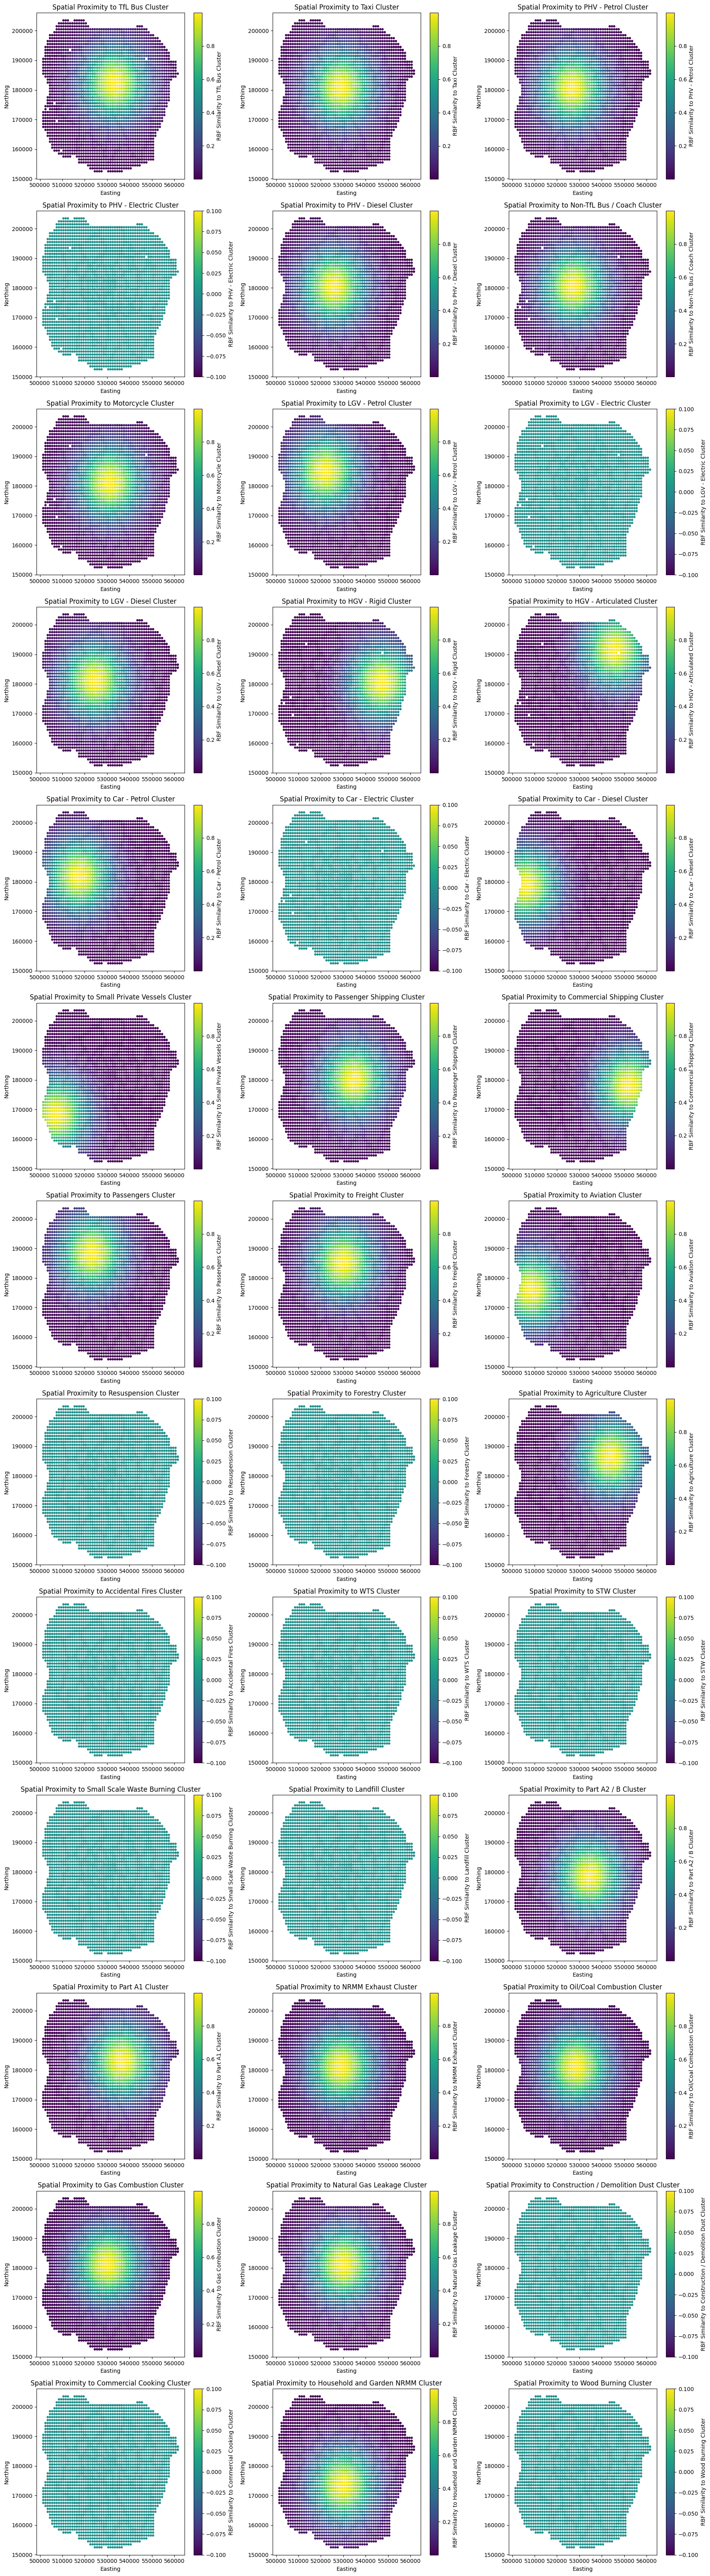

In [13]:
import math

unique_sources = emissions_2019['Source'].unique()
num_sources = len(unique_sources)

cols = 3
rows = math.ceil(num_sources / cols)

plt.figure(figsize=(6 * cols, 5 * rows))
for i, source in enumerate(unique_sources):
    mask = emissions_2019['Source'] == source
    plt.subplot(rows, cols, i + 1)
    plt.scatter(
        emissions_2019.loc[mask, 'Easting'], 
        emissions_2019.loc[mask, 'Northing'],
        c=cluster_similarities[mask, 0], cmap='viridis', s=10
    )
    plt.colorbar(label=f'RBF Similarity to {source} Cluster')
    plt.xlabel('Easting')
    plt.ylabel('Northing')
    plt.title(f'Spatial Proximity to {source} Cluster')

plt.tight_layout()
save_fig('cluster-spatial-proximity-all-sources')
plt.show()

## Split Train-Test Sets, Extract Labels

In [14]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(emissions_2019, test_size=0.2, stratify=emissions_2019['Source'])
X = strat_train_set.drop('co2', axis=1)
y = strat_train_set['co2'].copy()

In [15]:
X.head(5)

,Easting,Northing,Borough,Zone,Main Source Category,Sector,Source
89487,552500,169500,Non GLA,Non GLA,Industrial and Commercial,Waste,STW
20916,521500,186500,Brent,Inner,Transport,Road Transport,Motorcycle
6225,533500,200500,Non GLA,Non GLA,Transport,Road Transport,Taxi
141661,546500,189500,Redbridge,Outer,Domestic,Biomass,Wood Burning
90549,528500,168500,Merton,Outer,Industrial and Commercial,Waste,STW


In [16]:
y.describe()

count    115180.000000
mean        206.221486
std        3563.012127
min           0.000000
25%           0.000000
50%           0.000000
75%          22.283342
max      747457.600000
Name: co2, dtype: float64

## Transformation Pipeline

- Add features: proximity to central London (rbf)
- 1-hot encode categorical features
- Normalise other numerical features

> 'Source' could instead be ordinally encoded, based on largest contributor of emissions.

In [17]:
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

target_encoding_pipeline = make_pipeline(
    TargetEncoder(),
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ('cluster_simil_pipeline', ClusterProximity(), ['Northing', 'Easting', 'Source']),
    ('target_encoder_pipeline', target_encoding_pipeline, ['Borough', 'Main Source Category', 'Sector', 'Source']),
    ('num', StandardScaler(), ['Easting', 'Northing']),
    ('cat', OneHotEncoder(), ['Zone']),
])
X_prepared = preprocessing.fit_transform(X, y) # labels required for target encoding
y = np.log1p(y) # to address extreme skew
X_prepared.shape

(115180, 11)

In [18]:
feature_names = preprocessing.get_feature_names_out()
X_prepared_df = pd.DataFrame(X_prepared, columns=feature_names)
X_prepared_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115180 entries, 0 to 115179
Data columns (total 11 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   cluster_simil_pipeline__Source Cluster proximity  115180 non-null  float64
 1   target_encoder_pipeline__Borough                  115180 non-null  float64
 2   target_encoder_pipeline__Main Source Category     115180 non-null  float64
 3   target_encoder_pipeline__Sector                   115180 non-null  float64
 4   target_encoder_pipeline__Source                   115180 non-null  float64
 5   num__Easting                                      115180 non-null  float64
 6   num__Northing                                     115180 non-null  float64
 7   cat__Zone_Central                                 115180 non-null  float64
 8   cat__Zone_Inner                                   115180 non-null  float64
 9   cat_

## Fit Models, Compute Cross Validation Scores & Tune

In [19]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score

folds = 5

linear_regression = make_pipeline(preprocessing, Ridge())
linear_regression.fit(X, y)

linear_regression_maes = -cross_val_score(
    linear_regression, X, y, scoring='neg_mean_absolute_error', cv=folds, error_score='raise')

linear_regression_rmses = -cross_val_score(
    linear_regression, X, y, scoring='neg_root_mean_squared_error', cv=folds, error_score='raise')

linear_regression_r2_scores = cross_val_score(
    linear_regression, X, y, scoring='r2', cv=folds, error_score='raise')

print(f'Linear Regression Cross Validation ({folds} folds) Performance Metrics')
print('\nMAEs:\n' + str(pd.Series(linear_regression_maes).describe()))
print('\nRMSEs:\n' + str(pd.Series(linear_regression_rmses).describe()))
print('\nR2s:\n' + str(pd.Series(linear_regression_r2_scores).describe()))

Linear Regression Cross Validation (5 folds) Performance Metrics

MAEs:
count    5.000000
mean     0.806418
std      0.006147
min      0.799852
25%      0.801242
50%      0.807391
75%      0.808464
max      0.815143
dtype: float64

RMSEs:
count    5.000000
mean     1.293796
std      0.010827
min      1.281559
25%      1.287316
50%      1.292936
75%      1.297076
max      1.310095
dtype: float64

R2s:
count    5.000000
mean     0.706685
std      0.006495
min      0.699994
25%      0.700348
50%      0.706772
75%      0.712993
max      0.713318
dtype: float64


In [20]:
from sklearn.ensemble import RandomForestRegressor

folds = 3

random_forest_regressor = make_pipeline(preprocessing, RandomForestRegressor(n_jobs=-1))
random_forest_regressor.fit(X, y)

random_forest_maes = -cross_val_score(
    random_forest_regressor, X, y, scoring='neg_mean_absolute_error', cv=folds, error_score='raise')

random_forest_rmses = -cross_val_score(
    random_forest_regressor, X, y, scoring='neg_root_mean_squared_error', cv=folds, error_score='raise')

random_forest_r2_scores = cross_val_score(
    random_forest_regressor, X, y, scoring='r2', cv=folds, error_score='raise')

print(f'Random Forest Regressor Cross Validation ({folds} folds) Performance Metrics')
print('\nMAEs:\n' + str(pd.Series(random_forest_maes).describe()))
print('\nRMSEs:\n' + str(pd.Series(random_forest_rmses).describe()))
print('\nR2s:\n' + str(pd.Series(random_forest_r2_scores).describe()))

Random Forest Regressor Cross Validation (3 folds) Performance Metrics

MAEs:
count    3.000000
mean     0.569954
std      0.003311
min      0.566256
25%      0.568609
50%      0.570961
75%      0.571803
max      0.572645
dtype: float64

RMSEs:
count    3.000000
mean     1.080071
std      0.005730
min      1.073532
25%      1.077999
50%      1.082465
75%      1.083341
max      1.084216
dtype: float64

R2s:
count    3.000000
mean     0.795746
std      0.003975
min      0.792328
25%      0.793565
50%      0.794802
75%      0.797455
max      0.800108
dtype: float64


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

folds = 2

random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = {
    'random_forest__n_estimators': [100, 200],
    'random_forest__max_depth': [None, 20],
    'random_forest__min_samples_split': [2, 5],
    'random_forest__min_samples_leaf': [1],
    'random_forest__max_features': [4, 6, 8]
}
grid_search = GridSearchCV(random_forest_pipeline, param_grid, cv=folds,
                           scoring='neg_root_mean_squared_error', n_jobs=-1, 
                           verbose=1, error_score='raise')

grid_search.fit(X, y)

Fitting 2 folds for each of 24 candidates, totalling 48 fits


GridSearchCV(cv=2, error_score='raise',
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('cluster_simil_pipeline',
                                                                         ClusterProximity(),
                                                                         ['Northing',
                                                                          'Easting',
                                                                          'Source']),
                                                                        ('target_encoder_pipeline',
                                                                         Pipeline(steps=[('targetencoder',
                                                                                          TargetEncoder()),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['Borough',
                                                                          'Main '
                                                                          'Source '
                                                                          'Category',
                                                                          'Sector'...
                                                                         OneHotEncoder(),
                                                                         ['Zone'])])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'random_forest__max_depth': [None, 20],
                         'random_forest__max_features': [4, 6, 8],
                         'random_forest__min_samples_leaf': [1],
                         'random_forest__min_samples_split': [2, 5],
                         'random_forest__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [22]:
grid_search.best_params_

{'random_forest__max_depth': None,
 'random_forest__max_features': 4,
 'random_forest__min_samples_leaf': 1,
 'random_forest__min_samples_split': 2,
 'random_forest__n_estimators': 200}

In [23]:
from sklearn.ensemble import RandomForestRegressor

folds = 3

best_performing_model = RandomForestRegressor(
    max_features=4,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    n_jobs=-1,
)

random_forest_regressor = make_pipeline(preprocessing, best_performing_model)
random_forest_regressor.fit(X, y)

random_forest_maes = -cross_val_score(
    random_forest_regressor, X, y, scoring='neg_mean_absolute_error', cv=folds, error_score='raise')

random_forest_rmses = -cross_val_score(
    random_forest_regressor, X, y, scoring='neg_root_mean_squared_error', cv=folds, error_score='raise')

random_forest_r2_scores = cross_val_score(
    random_forest_regressor, X, y, scoring='r2', cv=folds, error_score='raise')

print(f'Random Forest Regressor Cross Validation ({folds} folds) Performance Metrics')
print('\nMAEs:\n' + str(pd.Series(random_forest_maes).describe()))
print('\nRMSEs:\n' + str(pd.Series(random_forest_rmses).describe()))
print('\nR2s:\n' + str(pd.Series(random_forest_r2_scores).describe()))

Random Forest Regressor Cross Validation (3 folds) Performance Metrics

MAEs:
count    3.000000
mean     0.573876
std      0.004000
min      0.569966
25%      0.571834
50%      0.573701
75%      0.575831
max      0.577960
dtype: float64

RMSEs:
count    3.000000
mean     1.070711
std      0.008668
min      1.060952
25%      1.067308
50%      1.073665
75%      1.075590
max      1.077515
dtype: float64

R2s:
count    3.000000
mean     0.799587
std      0.002972
min      0.796329
25%      0.798306
50%      0.800283
75%      0.801216
max      0.802148
dtype: float64


In [24]:
importances = random_forest_regressor.named_steps["randomforestregressor"].feature_importances_
feature_names = random_forest_regressor.named_steps["columntransformer"].get_feature_names_out()
sorted(zip(importances, feature_names), reverse=True)

[(np.float64(0.4354875925081062), 'target_encoder_pipeline__Source'),
 (np.float64(0.20449887236646586), 'target_encoder_pipeline__Sector'),
 (np.float64(0.1600864852513908),
  'cluster_simil_pipeline__Source Cluster proximity'),
 (np.float64(0.06068561922205208), 'num__Northing'),
 (np.float64(0.05971646749784198), 'num__Easting'),
 (np.float64(0.0369379859652989), 'target_encoder_pipeline__Borough'),
 (np.float64(0.031996855116758864),
  'target_encoder_pipeline__Main Source Category'),
 (np.float64(0.0034218441486518546), 'cat__Zone_Outer'),
 (np.float64(0.0031320884401235018), 'cat__Zone_Non GLA'),
 (np.float64(0.0030667557783429665), 'cat__Zone_Inner'),
 (np.float64(0.0009694337049669943), 'cat__Zone_Central')]

In [25]:
from xgboost import XGBRegressor

folds = 10

xgb_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.2,
    max_depth=6,
    n_estimators=1000,
    subsample=0.9
)

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("xgb", xgb_model),
])
xgb_pipeline.fit(X, y)

xgb_maes = -cross_val_score(
    xgb_pipeline, X, y, scoring='neg_mean_absolute_error', cv=folds, error_score='raise')

xgb_rmses = -cross_val_score(
    xgb_pipeline, X, y, scoring='neg_root_mean_squared_error', cv=folds, error_score='raise')

xgb_r2_scores = cross_val_score(
    xgb_pipeline, X, y, scoring='r2', cv=folds, error_score='raise')

print(f'XGBoost Cross Validation ({folds} folds) Performance Metrics')
print('\nMAEs:\n' + str(pd.Series(xgb_maes).describe()))
print('\nRMSEs:\n' + str(pd.Series(xgb_rmses).describe()))
print('\nR2s:\n' + str(pd.Series(xgb_r2_scores).describe()))

XGBoost Cross Validation (10 folds) Performance Metrics

MAEs:
count    10.000000
mean      0.557324
std       0.017738
min       0.528366
25%       0.545270
50%       0.558413
75%       0.567970
max       0.583490
dtype: float64

RMSEs:
count    10.000000
mean      0.962018
std       0.020860
min       0.923857
25%       0.950125
50%       0.963800
75%       0.977208
max       0.994553
dtype: float64

R2s:
count    10.000000
mean      0.836887
std       0.006892
min       0.824122
25%       0.834574
50%       0.839548
75%       0.841102
max       0.843802
dtype: float64


In [26]:
importances = xgb_pipeline.named_steps["xgb"].feature_importances_
feature_names = xgb_pipeline.named_steps["preprocessing"].get_feature_names_out()
sorted(zip(importances, feature_names), reverse=True)

[(np.float32(0.59627384), 'target_encoder_pipeline__Source'),
 (np.float32(0.0885433), 'cat__Zone_Non GLA'),
 (np.float32(0.057211287), 'target_encoder_pipeline__Main Source Category'),
 (np.float32(0.044265054), 'cat__Zone_Outer'),
 (np.float32(0.035106093), 'cat__Zone_Inner'),
 (np.float32(0.033953793), 'num__Northing'),
 (np.float32(0.03323404), 'target_encoder_pipeline__Sector'),
 (np.float32(0.031571772), 'num__Easting'),
 (np.float32(0.029763125), 'target_encoder_pipeline__Borough'),
 (np.float32(0.025060078), 'cluster_simil_pipeline__Source Cluster proximity'),
 (np.float32(0.025017722), 'cat__Zone_Central')]